In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# Run the benchmark and save the results to a CSV file
df = pd.read_csv('run_2026-03-30_13-00-47.csv') # Enter your CSV file name here

df = df[df["name"].str.contains("mean|stddev")]
df = df.reset_index(drop=True)

nbatch = [1, 5, 10, 15, 20]
method_names = ["Kernel", "Kernel_Sihao", "FFT", "FFT_Sihao"]
 

time_means = [[] for _ in range(4)]
time_stds = [[] for _ in range(4)]

time_per_map_means = [[] for _ in range(4)]
time_per_map_stds = [[] for _ in range(4)]

memory_means = [[] for _ in range(4)]
memory_stds = [[] for _ in range(4)]

for i in range(4):
    time_means[i] = df.iloc[10*i:10*(i+1):2]["real_time"].tolist()
    time_stds[i] = df.iloc[10*i+1:10*(i+1):2]["real_time"].tolist()

    time_per_map_means[i] = df.iloc[10*i:10*(i+1):2]["Time_per_batch"].tolist()
    time_per_map_stds[i] = df.iloc[10*i+1:10*(i+1):2]["Time_per_batch"].tolist()

    memory_means[i] = df.iloc[10*i:10*(i+1):2]["Memory"].tolist()
    memory_stds[i] = df.iloc[10*i+1:10*(i+1):2]["Memory"].tolist()

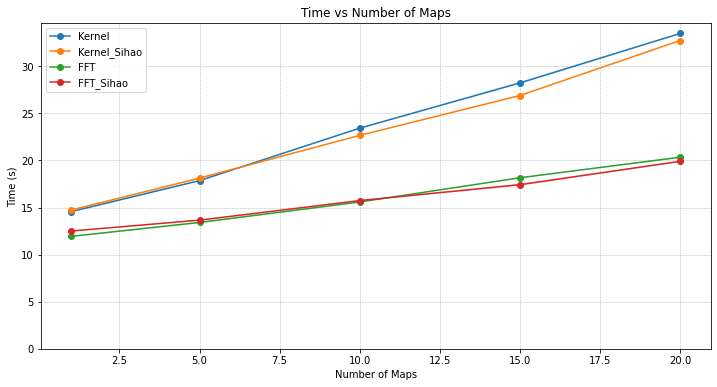

In [4]:
plt.figure(figsize=(12, 6))
for method_name, time_mean, time_std in zip(method_names, time_means, time_stds):
    time_mean = np.array(time_mean)
    time_std = np.array(time_std)

    plt.plot(
        nbatch,
        time_mean, 
        label=method_name,
        marker='o'
    )

    plt.fill_between(
        nbatch,
        time_mean - time_std,
        time_mean + time_std,
        alpha=0.2
    )

plt.xlabel('Number of Maps')
plt.ylabel('Time (s)')
plt.title('Time vs Number of Maps')
plt.legend()

plt.ylim(bottom=0)
plt.grid(True, which="both", ls="--", linewidth=0.5)

plt.show()

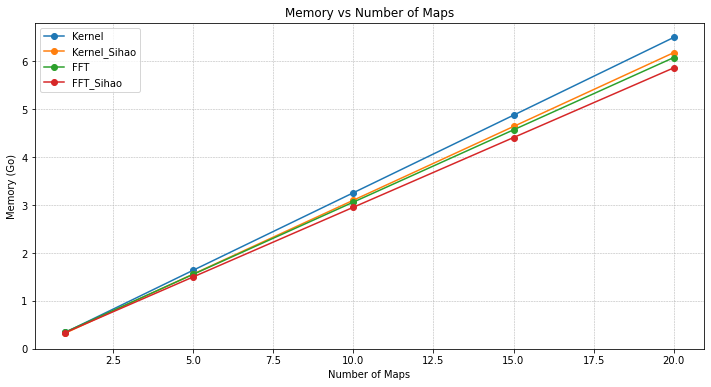

In [5]:
plt.figure(figsize=(12, 6))
for method_name, memory_mean, memory_std in zip(method_names, memory_means, memory_stds):
    memory_mean = np.array(memory_mean)/(1024**3)
    memory_std = np.array(memory_std)/(1024**3)

    plt.plot(
        nbatch, 
        memory_mean, 
        label=method_name,
        marker='o'
    )

    plt.fill_between(
        nbatch,
        memory_mean - memory_std,
        memory_mean + memory_std,
        alpha=0.2
    )

plt.xlabel('Number of Maps')
plt.ylabel('Memory (Go)')
plt.title('Memory vs Number of Maps')
plt.legend()

plt.ylim(bottom=0)
plt.grid(True, which="both", ls="--", linewidth=0.5)

plt.show()

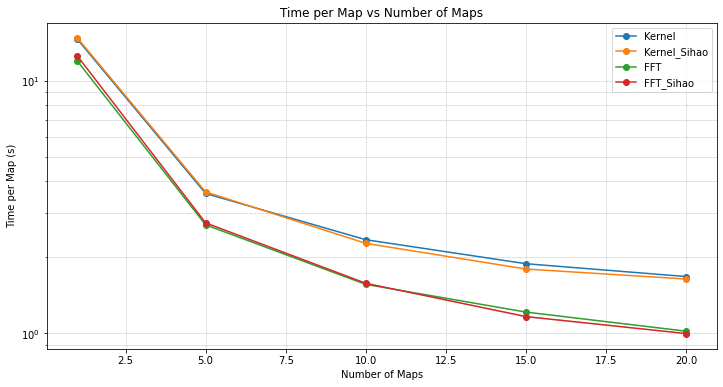

In [7]:
plt.figure(figsize=(12, 6))
for method_name, time_per_map_mean, time_per_map_std in zip(method_names, time_per_map_means, time_per_map_stds):
    time_per_map_mean = np.array(time_per_map_mean)
    time_per_map_std = np.array(time_per_map_std)

    plt.semilogy(
        nbatch, 
        time_per_map_mean, 
        label=method_name,
        marker='o'
    )

    plt.fill_between(
        nbatch,
        time_per_map_mean - time_per_map_std,
        time_per_map_mean + time_per_map_std,
        alpha=0.2
    )

plt.xlabel('Number of Maps')
plt.ylabel('Time per Map (s)')
plt.title('Time per Map vs Number of Maps')
plt.legend()

plt.grid(True, which="both", ls="--", linewidth=0.5)

plt.show()